# **Neural Network Backpropagation, Mathematically Explained**

In this Python notebook, we will build a Multilayer Perceptron (MLP), otherwise known as the Feedforward Neural Network, entirely from scratch using full **NumPy**. We will build the network from the ground up to understand exactly how the math works behind the scenes.

Please select the GPU in the runtime options. The code will have comments and explanations for clarity. Happy Learning!

—AI, But Simple Team

## **The Mathematical Foundation**

We treat the neural network as a differentiable function $f(x; W) = \hat{y}$.
* $x$: Input vector.
* $W$: Weight matrices (parameters).
* $\hat{y}$: The predicted output.

### **The Forward Pass**
Data flows through layers. For a single layer $l$, the computation is split into a linear transformation and a non-linear activation.

1.  **Linear Transformation($z$):**
    $$z^{(l)} = W^{(l)} \cdot a^{(l-1)} + b^{(l)}$$
    Here, $a^{(l-1)}$ is the input from the previous layer.

2.  **Activation ($a$):**
    We apply a non-linear function so the network can learn non-linear patterns. We use the **Sigmoid** function:
    
    $$a^{(l)} = \sigma(z^{(l)}) = \frac{1}{1 + e^{-z^{(l)}}}$$

### **The Loss Function**
To measure performance, we use the **Mean Squared Error (MSE)** loss function. This is some measure of "distance" or error between our prediction $\hat{y}$ and the truth $y$.
$$L = \frac{1}{2} (y - \hat{y})^2$$
*(Note: The loss term is scaled by $\frac{1}{2}$ to make the derivative cleaner).*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

def sigmoid(x):
    """
    Sigmoid Activation Function with formula: 1 / (1 + e^-x).
    Maps input 'x' to a value between 0 and 1.
    """
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    """
    The derivative of the Sigmoid function d/dz sigmoid(z) = a * (1 - a)
    We assume 'x' is the activated output (a).

    """
    return x * (1 - x)

## **Backpropagation**

We need to update weights $W$ to minimize Loss $L$. To do this, we need the gradient $\frac{\partial L}{\partial W}$.

Computing this directly for every weight is expensive. Instead, we use the **Chain Rule** to propagate error terms ($\delta$) backward from the output.


### **Output Layer Delta ($\delta^{(2)}$)**
How much did the output layer contribute to the error?
$$\delta^{(2)} = \frac{\partial L}{\partial a^{(2)}} \cdot \frac{\partial a^{(2)}}{\partial z^{(2)}}$$
Substituting the MSE derivative and Sigmoid derivative:
$$\delta^{(2)} = (a^{(2)} - y) \odot \sigma'(a^{(2)})$$

### **Hidden Layer Delta ($\delta^{(1)}$)**
We propagate $\delta^{(2)}$ backwards through the weights $W^{(2)}$ to find the error at the hidden layer.
$$\delta^{(1)} = (\delta^{(2)} \cdot (W^{(2)})^T) \odot \sigma'(a^{(1)})$$

### **Weight Updates (Gradient Descent)**
Once we have the deltas, the gradient for any weight matrix is simply the **dot product** of the previous layer's activation and the current layer's delta.

$$W_{new} = W_{old} - \alpha \cdot \frac{\partial L}{\partial W}$$
$$\frac{\partial L}{\partial W} = a_{prev}^T \cdot \delta_{current}$$

In [ ]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        """
        Initialize the network with random weights and zero biases.
        """
        # Layer 1: Input to Hidden
        self.W1 = np.random.uniform(-1, 1, (input_size, hidden_size))
        self.b1 = np.zeros((1, hidden_size))

        # Layer 2: Hidden to Output
        self.W2 = np.random.uniform(-1, 1, (hidden_size, output_size))
        self.b2 = np.zeros((1, output_size))

        # Store loss history for plotting
        self.loss_history = []

    def forward(self, x):
        """
        Perform Forward Pass
        """
        # Layer 1
        self.z1 = np.dot(x, self.W1) + self.b1
        # Activation
        self.a1 = sigmoid(self.z1)

        # Layer 2
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)

        return self.a2

    def backward(self, x, y, output, learning_rate):
        """
        Perform Backpropagation
        """
        # Number of samples in the batch
        m = x.shape[0]

        # Output layer error
        output_error = output - y

        # Output delta
        delta_output = output_error * sigmoid_derivative(output)

        # Hidden layer error (backpropagated), dot product of output delta and second layer weights transpose
        hidden_error = delta_output.dot(self.W2.T)

        # Hidden layer delta
        delta_hidden = hidden_error * sigmoid_derivative(self.a1)

        # Weight update for second layer
        self.W2 -= learning_rate * self.a1.T.dot(delta_output)
        self.b2 -= learning_rate * np.sum(delta_output, axis=0, keepdims=True)

        # Weight update for first layer
        self.W1 -= learning_rate * x.T.dot(delta_hidden)
        self.b1 -= learning_rate * np.sum(delta_hidden, axis=0, keepdims=True)

    def train(self, x, y, epochs=10000, learning_rate=0.1):
        """
        Training Loop
        """
        for epoch in range(epochs):
            # 1. Forward Pass
            output = self.forward(x)

            # 2. Backward Pass
            self.backward(x, y, output, learning_rate)

            # 3. Compute Loss (MSE)
            loss = np.mean(np.square(y - output))
            self.loss_history.append(loss)

            # Print progress every 2000 epochs
            if epoch % 2000 == 0:
                print(f"Epoch {epoch}: Loss {loss:.5f}")

## **An Example**

Let's check our current code using a manual calculation example. Feel free to test this using the values in the original article.

**The Setup:**
* Input $x$: `[0.5, -0.2]`
* Target $y$: `1.0`
* We will hardcode specific weights for testing

We will run **one single pass** and print the intermediate values (Gradients).

In [ ]:
x_manual = np.array([[0.5, -0.2]])
y_target = np.array([[1.0]])

# Initialize weights manually for demonstration
W1_manual = np.array([[0.1, 0.2],
                      [-0.1, 0.5]])
b1_manual = np.array([[0.0, 0.0]])

W2_manual = np.array([[0.6],
                      [-0.3]])
b2_manual = np.array([[0.0]])

# Forward Pass
print("Forward Pass")
# Layer 1
z1 = np.dot(x_manual, W1_manual) + b1_manual
a1 = sigmoid(z1)
print(f"Hidden Activation: {np.round(a1, 4)}")

# Layer 2
z2 = np.dot(a1, W2_manual) + b2_manual
a2 = sigmoid(z2)
print(f"Output Prediction: {np.round(a2, 4)}")

# Backwards Pass + Backprop
print("\nBackward Pass")
error = a2 - y_target
print(f"Raw Error: {np.round(error, 4)}")

# Output Delta
delta2 = error * sigmoid_derivative(a2)
print(f"Output Delta: {np.round(delta2, 4)}")

# Gradient for W2
grad_W2 = np.dot(a1.T, delta2)
print(f"Gradient W2:\n{np.round(grad_W2, 4)}")

# Hidden Delta
# Propagate error back through W2
error_hidden = np.dot(delta2, W2_manual.T)
delta1 = error_hidden * sigmoid_derivative(a1)
print(f"Hidden Delta: {np.round(delta1, 4)}")

# Step D: Gradient for W1
grad_W1 = np.dot(x_manual.T, delta1)
print(f"Gradient W1:\n{np.round(grad_W1, 4)}")

Forward Pass
Hidden Activation: [[0.5175 0.5   ]]
Output Prediction: [[0.54]]

Backward Pass
Raw Error: [[-0.46]]
Output Delta: [[-0.1143]]
Gradient W2:
[[-0.0591]
 [-0.0571]]
Hidden Delta: [[-0.0171  0.0086]]
Gradient W1:
[[-0.0086  0.0043]
 [ 0.0034 -0.0017]]


## **Solving XOR**

Now we apply our `NeuralNetwork` class to the XOR problem. XOR is non-linear, meaning a simple line cannot separate the classes.
* (0,0) → 0
* (0,1) → 1
* (1,0) → 1
* (1,1) → 0

We will train for 10000 epochs (high accuracy convergence) and visualize the **Decision Boundary**.

Starting Training...
Epoch 0: Loss 0.26292
Epoch 2000: Loss 0.11315
Epoch 4000: Loss 0.00968
Epoch 6000: Loss 0.00410
Epoch 8000: Loss 0.00251


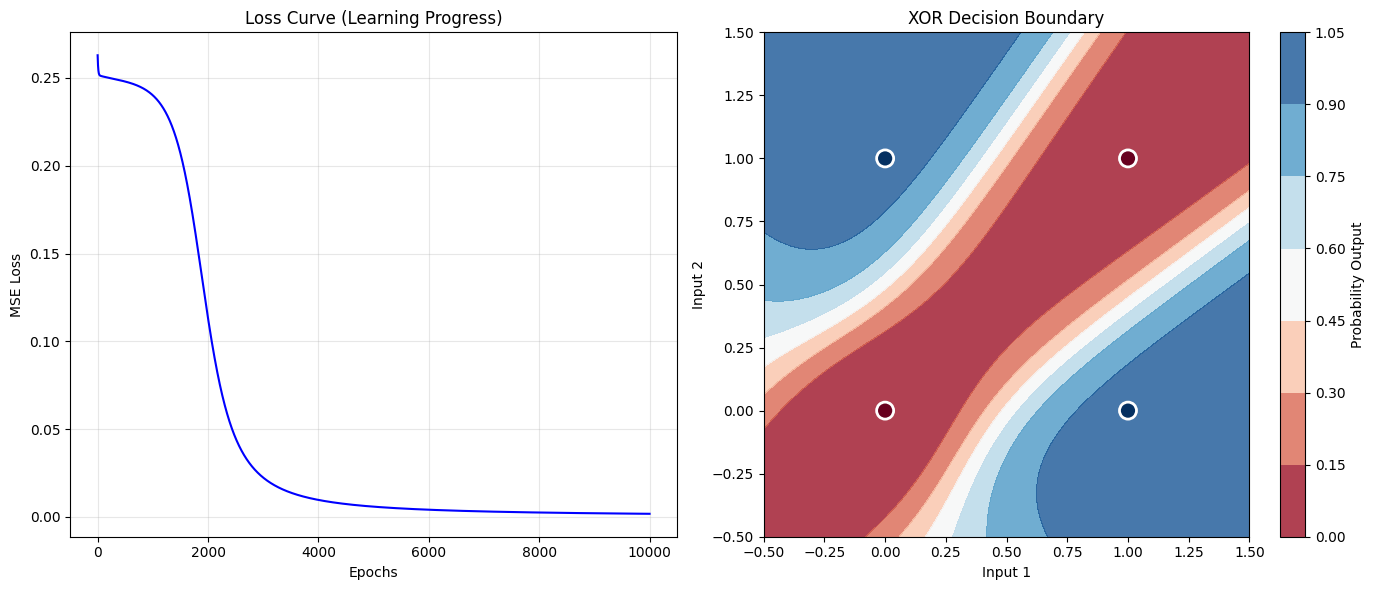


Final Predictions vs Targets:
Input: [0 0] | Target: 0 | Prediction: 0.0278
Input: [0 1] | Target: 1 | Prediction: 0.9565
Input: [1 0] | Target: 1 | Prediction: 0.9583
Input: [1 1] | Target: 0 | Prediction: 0.0524


In [ ]:
# Prepare Data
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

# Initialize Network
nn = NeuralNetwork(input_size=2, hidden_size=4, output_size=1)

print("Starting Training...")
nn.train(X, y, epochs=10000, learning_rate=0.1)

plt.figure(figsize=(14, 6))

# Subplot 1: Loss History
plt.subplot(1, 2, 1)
plt.plot(nn.loss_history, color='blue')
plt.title("Loss Curve (Learning Progress)")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.grid(True, alpha=0.3)

# Subplot 2: Decision Boundary
plt.subplot(1, 2, 2)
# Create a grid of points
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 100), np.linspace(-0.5, 1.5, 100))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Predict for every point on the grid
preds = nn.forward(grid_points)
preds = preds.reshape(xx.shape)

# Plot contours
plt.contourf(xx, yy, preds, cmap='RdBu', alpha=0.8)
plt.colorbar(label='Probability Output')

# Plot original data points
plt.scatter(X[:,0], X[:,1], c=y.ravel(), cmap='RdBu', edgecolors='white', s=150, linewidth=2)
plt.title("XOR Decision Boundary")
plt.xlabel("Input 1")
plt.ylabel("Input 2")

plt.tight_layout()
plt.show()

print("\nFinal Predictions vs Targets:")
final_preds = nn.forward(X)
for i in range(len(X)):
    print(f"Input: {X[i]} | Target: {y[i][0]} | Prediction: {final_preds[i][0]:.4f}")